# Regresión lineal simple - Titanic

## Importar las librerías

In [ ]:
#Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Librerías regresion lineal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## Cargar datos

In [ ]:
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Selección de variables

In [ ]:
# Copio solo las columnas necesarias
df_model = df[["survived", "fare"]].copy()
# Borro todo las filas vacias
df_model = df_model.dropna()
# Asegurar que fare sea un número
df_model["fare"] = pd.to_numeric(df_model["fare"], errors="coerce")
df_model.head()

,survived,fare
0,0,7.2500
1,1,71.2833
2,1,7.9250
3,1,53.1000
4,0,8.0500


## Visualización

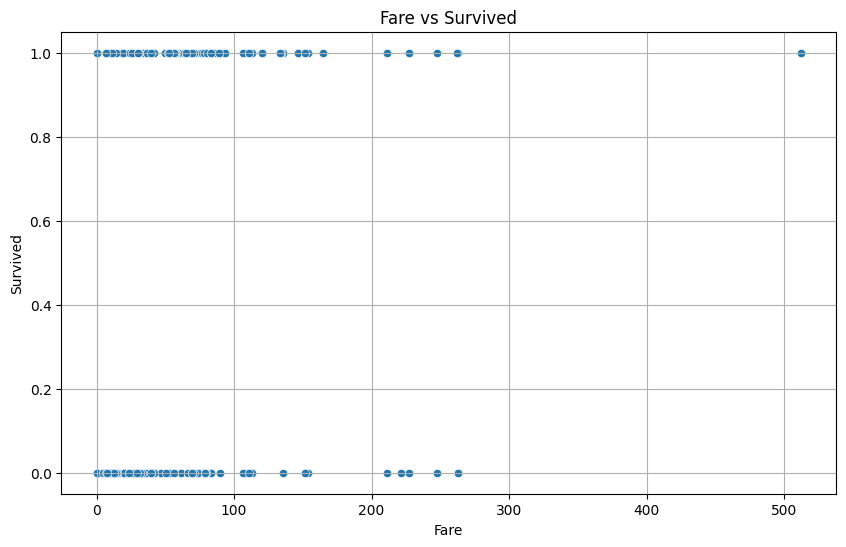

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_model, x="fare", y="survived")

plt.title("Fare vs Survived")
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.grid(True)
plt.show()

## Separación de datos


In [ ]:
X = df_model[["fare"]]
y = df_model["survived"]

#Separar el dataset en entrenamiento y test

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

len(X_train), len(X_test)

(712, 179)

## Ejecutar el modelo de regresión


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Evaluar el modelo

In [ ]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(r2)

0.07884938019727206


## Visualización de la regresión

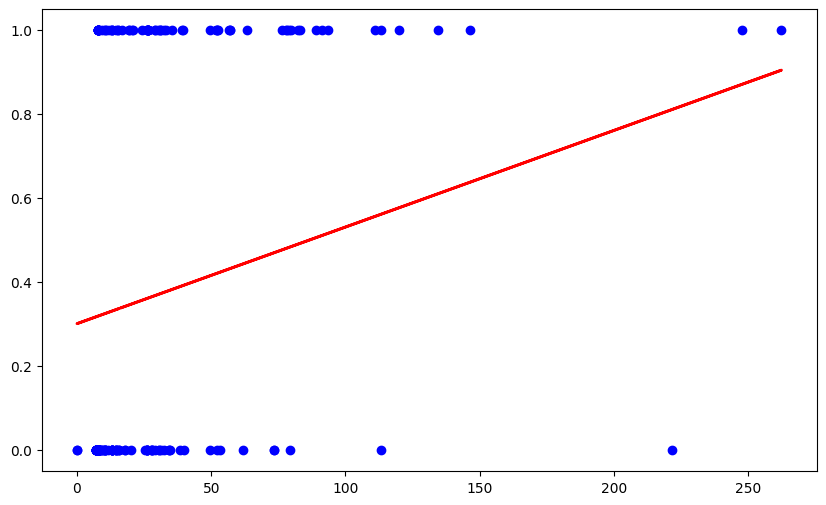

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color="blue", label="Datos reales")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regresión")
plt.show()